# Treinamento Q-Learning — Decisão Financeira

Notebook de treinamento do agente Q-Learning para o problema de portfólio simplificado (T2).  
O loop varia **learning_rate** × **epsilon_decay_type** e armazena os resultados para análise posterior.

## 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imports do projeto
from env.env import StockMarketEnv
from agents.q_learning import QLearningAgent
from agents.sarsa import SARSAAgent

from datetime import datetime

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

In [2]:
NUM_EPISODES = 5000

# ── Parâmetros variáveis ──────────────────────────────────────────────
AGENT_TYPES = ["Q-Learning", "SARSA"]
LEARNING_RATES      = [0.0001, 0.0005, 0.001, 0.005, 0.01]
EPSILON_DECAY_TYPES = ["constant", "linear", "exponential"]
GAMMA_VALUES        = [0.8, 0.9, 0.95, 0.99]

# ── Caminhos dos dados ────────────────────────────────────────────────
TRAIN_DATA_PATH = "data/amzn_transformed_train.csv"
TEST_DATA_PATH  = "data/amzn_transformed_test.csv"
total_combos = len(AGENT_TYPES) * len(LEARNING_RATES) * len(EPSILON_DECAY_TYPES) * len(GAMMA_VALUES)
print(f"Configurações: {len(AGENT_TYPES)} Agentes × {len(LEARNING_RATES)} LRs × {len(EPSILON_DECAY_TYPES)} Decays × {len(GAMMA_VALUES)} Gammas = {total_combos} combinações")

Configurações: 2 Agentes × 5 LRs × 3 Decays × 4 Gammas = 120 combinações


## 2 — Funções Auxiliares

In [3]:
def train_agent(env, agent, n_episodes, is_sarsa):
    """
    Treina os agente Q-learning ou SARSA por n_episodes.
    
    Retorna um dicionário com métricas por episódio:
        - episode_rewards:  lista de recompensa acumulada por episódio
        - episode_epsilons: lista de epsilon ao final de cada episódio
        - episode_steps:    lista de número de steps por episódio
    """
    episode_rewards  = []
    episode_epsilons = []
    episode_steps    = []

    for ep in range(n_episodes):
        state = env.reset()

        # Se for SARSA, a primeira ação deve ser escolhida antes do loop
        if is_sarsa:
            action = agent.choose_action(state, training=True)

        total_reward = 0.0
        steps = 0
        done = False

        while not done:
            # Se for Q-Learning, a ação atual é escolhida no início da iteração
            if not is_sarsa:
                action = agent.choose_action(state, training=True)

            next_state, reward, done = env.step(action)

            # Ramificação do Update
            if is_sarsa:
                # SARSA: escolhe a próxima ação agora, atualiza, e a guarda para o próximo loop
                next_action = agent.choose_action(next_state, training=True)
                agent.update(state, action, reward, next_state, next_action, done)
                
                # A ação atual passa a ser a próxima ação que já foi decidida
                action = next_action 
            else:
                # Q-Learning: o update clássico não precisa saber qual a próxima ação real
                agent.update(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            steps += 1

        # Atualiza epsilon ao final do episódio
        agent.update_epsilon(ep)

        episode_rewards.append(total_reward)
        episode_epsilons.append(agent.epsilon)
        episode_steps.append(steps)

        if ep % 50 == 0: 
            print(f"Ep: {ep}/{n_episodes}")

    return {
        "episode_rewards":  episode_rewards,
        "episode_epsilons": episode_epsilons,
        "episode_steps":    episode_steps,
        }

def evaluate_agent(data_path, agent):
    """
    Avalia o agente de forma greedy (sem exploração) em um dataset.
    
    Retorna:
        - total_reward: recompensa acumulada total
        - step_rewards: lista de recompensa por step
        - positions:    lista de posições ao longo dos steps
    """
    env = StockMarketEnv(data_path)
    state = env.reset()

    total_reward = 0.0
    step_rewards = []
    positions    = []
    done = False

    while not done:
        action = agent.choose_action(state, training=False)
        next_state, reward, done = env.step(action)

        total_reward += reward
        step_rewards.append(reward)
        positions.append(env.position)

        state = next_state

    return {
        "total_reward": total_reward,
        "step_rewards": step_rewards,
        "positions":    positions,
        }

In [4]:
inicio = datetime.now()
print(f"Início: {inicio.strftime('%Y-%m-%d %H:%M:%S')}")

Início: 2026-04-28 14:21:19


In [5]:
# Dicionário para armazenar todos os resultados
# Chave: (agent_type, decay_type, lr) → valor: dict com métricas + agente treinado
results = {}
combo_idx = 0

for agent_type in AGENT_TYPES:
    for decay_type in EPSILON_DECAY_TYPES:
        for lr in LEARNING_RATES:
            for gamma in GAMMA_VALUES:
                combo_idx += 1
                print(f"\n[{combo_idx}/{total_combos}] Agente={agent_type} decay={decay_type}, lr={lr}, gamma={gamma}")

                # Cria environment e agente
                env = StockMarketEnv(TRAIN_DATA_PATH)

                # Instancia o agente correto dependendo do loop atual
                if agent_type == "Q-Learning":
                    agent = QLearningAgent(
                        env=env,
                        learning_rate=lr,
                        gamma=gamma,
                        epsilon_decay_type=decay_type,
                    )
                    is_sarsa_flag = False
                else:
                    agent = SARSAAgent(
                        env=env,
                        learning_rate=lr,
                        gamma=gamma,
                        epsilon_decay_type=decay_type,
                    )
                    is_sarsa_flag = True
                
                # Treina
                metrics = train_agent(env, agent, NUM_EPISODES, is_sarsa_flag)

                # Armazena resultados
                key = (agent_type, decay_type, lr, gamma)
                results[key] = {
                    "metrics": metrics,
                    "agent":   agent,
                }

                # Resumo rápido
                mean_last_100 = np.mean(metrics["episode_rewards"][-100:])
                print(f"  → Reward médio (últimos 100 eps): {mean_last_100:.4f}")
                print(f"  → Epsilon final: {metrics['episode_epsilons'][-1]:.4f}")
                print(f"  → Estados na Q-table: {agent.q_table.shape}")

print("\n✅ Treinamento concluído para todas as combinações!")


[1/120] Agente=Q-Learning decay=constant, lr=0.0001, gamma=0.8
Ep: 0/5000
Ep: 50/5000
Ep: 100/5000
Ep: 150/5000
Ep: 200/5000
Ep: 250/5000
Ep: 300/5000
Ep: 350/5000
Ep: 400/5000
Ep: 450/5000
Ep: 500/5000
Ep: 550/5000
Ep: 600/5000
Ep: 650/5000
Ep: 700/5000
Ep: 750/5000
Ep: 800/5000
Ep: 850/5000
Ep: 900/5000
Ep: 950/5000
Ep: 1000/5000
Ep: 1050/5000
Ep: 1100/5000
Ep: 1150/5000
Ep: 1200/5000
Ep: 1250/5000
Ep: 1300/5000
Ep: 1350/5000
Ep: 1400/5000
Ep: 1450/5000
Ep: 1500/5000
Ep: 1550/5000
Ep: 1600/5000
Ep: 1650/5000
Ep: 1700/5000
Ep: 1750/5000
Ep: 1800/5000
Ep: 1850/5000
Ep: 1900/5000
Ep: 1950/5000
Ep: 2000/5000
Ep: 2050/5000
Ep: 2100/5000
Ep: 2150/5000
Ep: 2200/5000
Ep: 2250/5000
Ep: 2300/5000
Ep: 2350/5000
Ep: 2400/5000
Ep: 2450/5000
Ep: 2500/5000
Ep: 2550/5000
Ep: 2600/5000
Ep: 2650/5000
Ep: 2700/5000
Ep: 2750/5000
Ep: 2800/5000
Ep: 2850/5000
Ep: 2900/5000
Ep: 2950/5000
Ep: 3000/5000
Ep: 3050/5000
Ep: 3100/5000
Ep: 3150/5000
Ep: 3200/5000
Ep: 3250/5000
Ep: 3300/5000
Ep: 3350/5000
Ep: 340

In [6]:
fim = datetime.now()
print(f"Fim: {fim.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Duração: {fim - inicio}")

Fim: 2026-04-28 22:55:50
Duração: 8:34:30.805986


## 3 - Value Iteration


In [7]:
from agents.value_iteration import ValueIterationAgent

VI_TRANSACTION_COSTS = [0.01, 0.001, 0.0001]
VI_GAMMA = 0.9
VI_THETA = 1e-10
VI_MAX_ITERATIONS = 10000
VI_REWARD_EVAL_INTERVAL = 1000

vi_results_final = {}

for tc in VI_TRANSACTION_COSTS:
    vi_env = StockMarketEnv(TRAIN_DATA_PATH)
    vi_agent = ValueIterationAgent(
        env=vi_env,
        gamma=VI_GAMMA,
        theta=VI_THETA,
        max_iterations=VI_MAX_ITERATIONS,
        transaction_cost_override=tc,
        state_shape=(2, 2, 2, 2),
        actions=np.array([-1, 0, 1]),
    )

    vi_history = []
    total_bellman_backups = 0
    converged_at = None
    reward_trace = {
        "iterations": [],
        "train_reward": [],
        "test_reward": [],
    }

    for iteration in range(vi_agent.max_iterations):
        delta = 0.0

        for state in np.ndindex(vi_agent.value_table.shape):
            old_value = vi_agent.value_table[state]
            vi_agent.update(state)
            delta = max(delta, abs(vi_agent.value_table[state] - old_value))
            total_bellman_backups += 1

        vi_history.append(delta)

        if converged_at is None and delta < vi_agent.theta:
            converged_at = iteration

        if iteration % VI_REWARD_EVAL_INTERVAL == 0 or iteration == vi_agent.max_iterations - 1:
            train_eval = evaluate_agent(TRAIN_DATA_PATH, vi_agent)
            test_eval = evaluate_agent(TEST_DATA_PATH, vi_agent)
            reward_trace["iterations"].append(iteration)
            reward_trace["train_reward"].append(train_eval["total_reward"])
            reward_trace["test_reward"].append(test_eval["total_reward"])

    train_eval = evaluate_agent(TRAIN_DATA_PATH, vi_agent)
    test_eval = evaluate_agent(TEST_DATA_PATH, vi_agent)
    train_total = train_eval["total_reward"]
    train_steps = len(train_eval["step_rewards"])
    test_total = test_eval["total_reward"]
    test_steps = len(test_eval["step_rewards"])

    policy_flat = vi_agent.policy_table.flatten()
    unique_actions, counts = np.unique(policy_flat, return_counts=True)
    action_stats = {int(action): int(count) for action, count in zip(unique_actions, counts)}

    print(f"tc={tc} | converge={converged_at} | backups={total_bellman_backups:,} | train={train_total:.6f} | test={test_total:.6f}")
    print(f"  deltas: first={vi_history[0]:.6e} last={vi_history[-1]:.6e} checkpoints={len(reward_trace['iterations'])}")
    print(f"  actions: sell={action_stats.get(-1, 0)} hold={action_stats.get(0, 0)} buy={action_stats.get(1, 0)}")

    vi_results_final[tc] = {
        "agent": vi_agent,
        "train_reward": train_total,
        "test_reward": test_total,
        "train_steps": train_steps,
        "test_steps": test_steps,
        "total_backups": total_bellman_backups,
        "iterations": len(vi_history),
        "converged_at": converged_at,
        "history": vi_history,
        "reward_trace": reward_trace,
        "train_eval": train_eval,
        "test_eval": test_eval,
    }

best_tc = max(VI_TRANSACTION_COSTS, key=lambda t: vi_results_final[t]["test_reward"])
best_vi_agent = vi_results_final[best_tc]["agent"]

print()
print(f"best_tc={best_tc} | best_test_reward={vi_results_final[best_tc]['test_reward']:.6f} | best_converged_at={vi_results_final[best_tc]['converged_at']}")

tc=0.01 | converge=110 | backups=160,000 | train=0.000000 | test=0.000000
  deltas: first=3.012528e-03 last=0.000000e+00 checkpoints=11
  actions: sell=8 hold=8 buy=0
tc=0.001 | converge=109 | backups=160,000 | train=3.738724 | test=1.828293
  deltas: first=1.626333e-03 last=0.000000e+00 checkpoints=11
  actions: sell=6 hold=6 buy=4
tc=0.0001 | converge=109 | backups=160,000 | train=3.651248 | test=1.643249
  deltas: first=1.631606e-03 last=0.000000e+00 checkpoints=11
  actions: sell=6 hold=5 buy=5

best_tc=0.001 | best_test_reward=1.828293 | best_converged_at=109


### 3.1 — Visualizações do Value Iteration



best_tc=0.001
converged_at=109
iterations=10000
backups=160,000
train_reward=3.738724
test_reward=1.828293
value_min=0.000613 value_max=0.005169 value_mean=0.002645
policy_sell=6 policy_hold=6 policy_buy=4


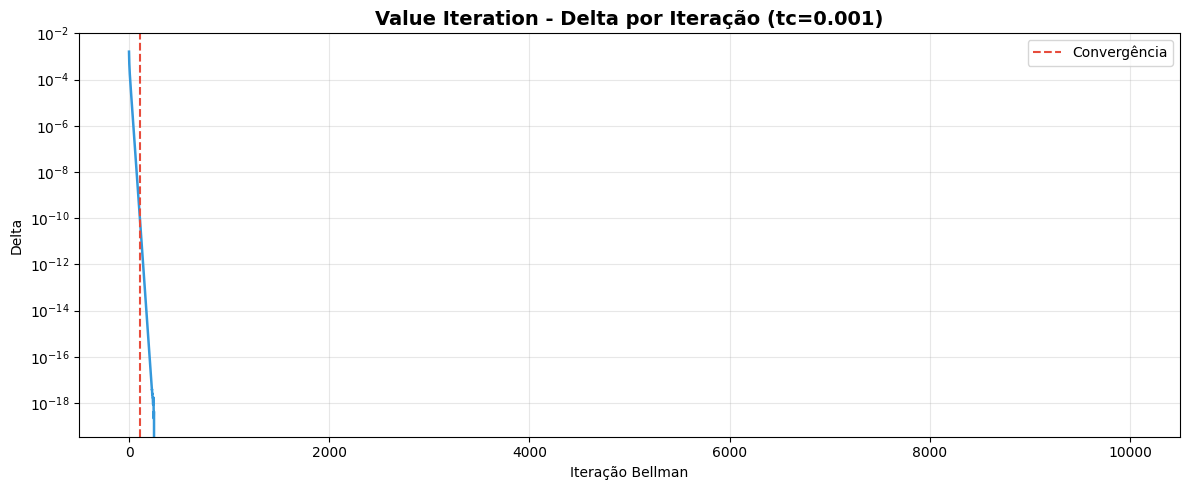

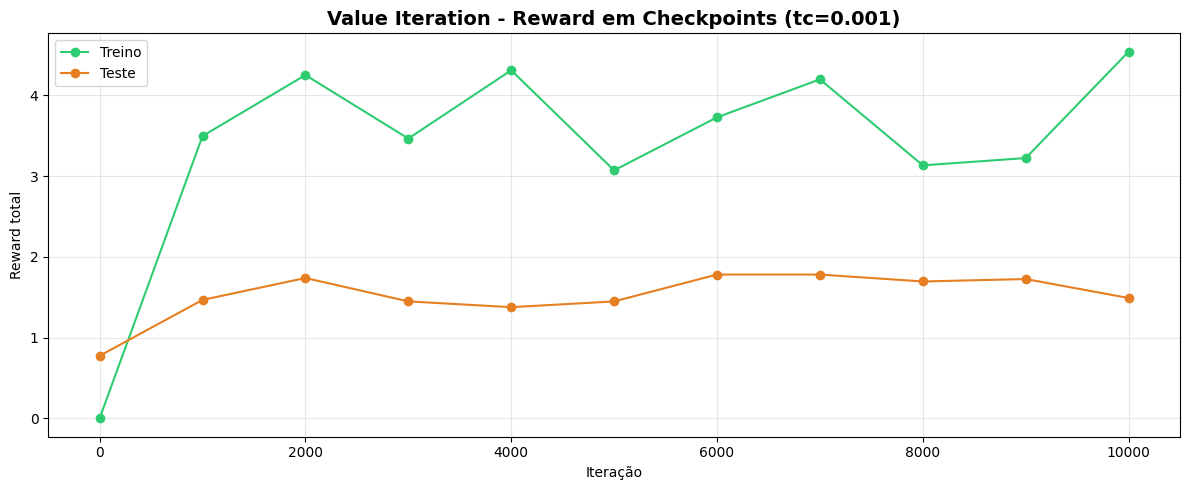

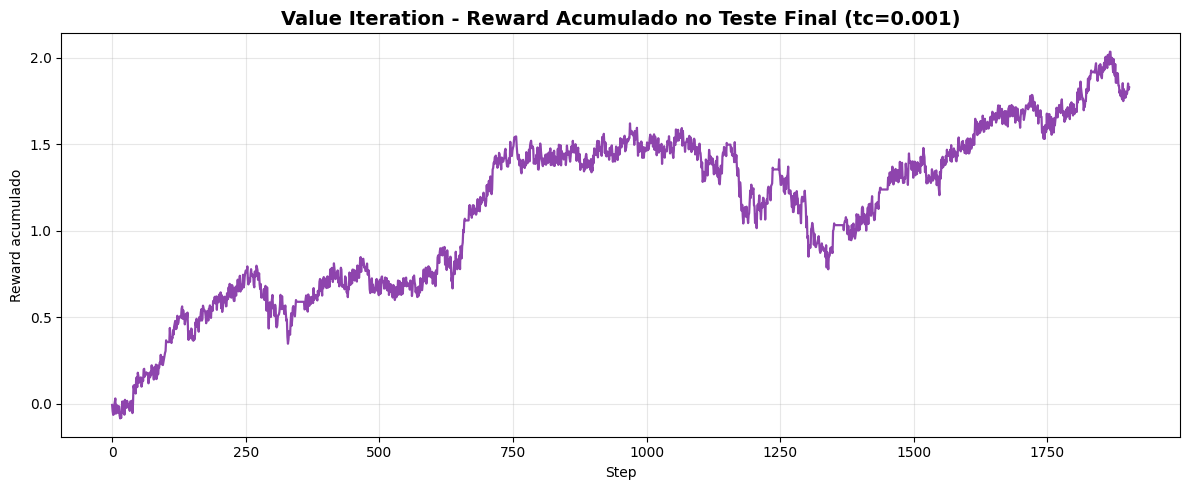

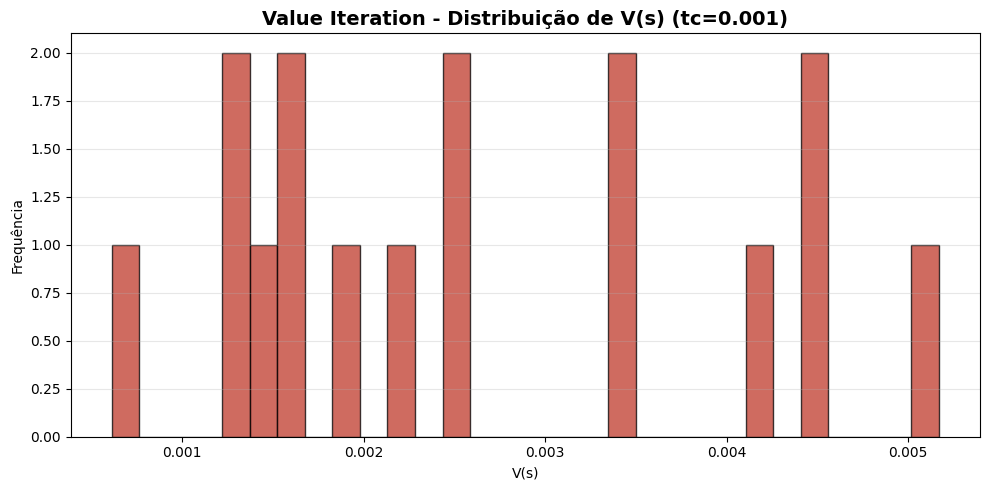

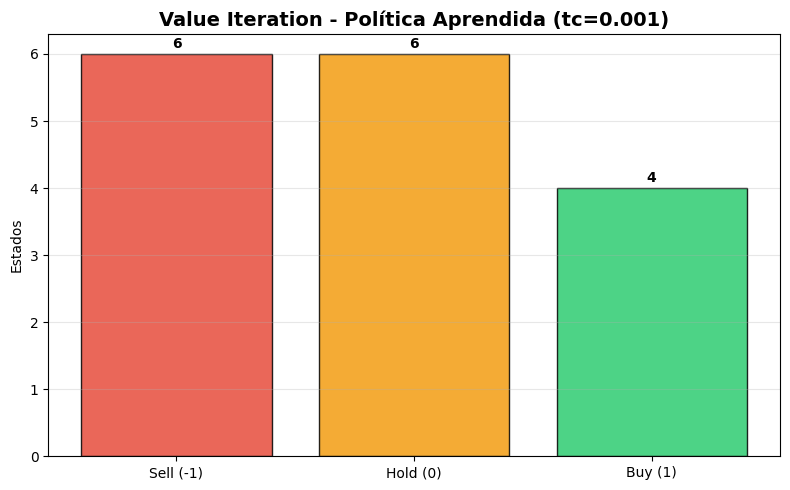

In [8]:
vi_plot_agent = best_vi_agent if 'best_vi_agent' in globals() else vi_results_final[best_tc]['agent']
vi_plot_data = vi_results_final[best_tc]

print(f"best_tc={best_tc}")
print(f"converged_at={vi_plot_data['converged_at']}")
print(f"iterations={vi_plot_data['iterations']}")
print(f"backups={vi_plot_data['total_backups']:,}")
print(f"train_reward={vi_plot_data['train_reward']:.6f}")
print(f"test_reward={vi_plot_data['test_reward']:.6f}")
print(f"value_min={vi_plot_agent.value_table.min():.6f} value_max={vi_plot_agent.value_table.max():.6f} value_mean={vi_plot_agent.value_table.mean():.6f}")
print(f"policy_sell={np.sum(vi_plot_agent.policy_table == -1)} policy_hold={np.sum(vi_plot_agent.policy_table == 0)} policy_buy={np.sum(vi_plot_agent.policy_table == 1)}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vi_plot_data['history'], color='#3498db', linewidth=1.8)
if vi_plot_data['converged_at'] is not None:
    ax.axvline(vi_plot_data['converged_at'], color='#e74c3c', linestyle='--', linewidth=1.5, label='Convergência')
ax.set_title(f"Value Iteration - Delta por Iteração (tc={best_tc})", fontsize=14, fontweight='bold')
ax.set_xlabel('Iteração Bellman')
ax.set_ylabel('Delta')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

reward_trace = vi_plot_data['reward_trace']
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reward_trace['iterations'], reward_trace['train_reward'], marker='o', linewidth=1.5, label='Treino', color='#2ecc71')
ax.plot(reward_trace['iterations'], reward_trace['test_reward'], marker='o', linewidth=1.5, label='Teste', color='#e67e22')
ax.set_title(f"Value Iteration - Reward em Checkpoints (tc={best_tc})", fontsize=14, fontweight='bold')
ax.set_xlabel('Iteração')
ax.set_ylabel('Reward total')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
cumulative_rewards = np.cumsum(vi_plot_data['test_eval']['step_rewards'])
ax.plot(cumulative_rewards, color='#8e44ad', linewidth=1.6)
ax.set_title(f"Value Iteration - Reward Acumulado no Teste Final (tc={best_tc})", fontsize=14, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Reward acumulado')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
values = vi_plot_agent.value_table.flatten()
ax.hist(values, bins=30, color='#c0392b', edgecolor='black', alpha=0.75)
ax.set_title(f"Value Iteration - Distribuição de V(s) (tc={best_tc})", fontsize=14, fontweight='bold')
ax.set_xlabel('V(s)')
ax.set_ylabel('Frequência')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

policy_flat = vi_plot_agent.policy_table.flatten()
action_labels = [-1, 0, 1]
action_counts = [np.sum(policy_flat == a) for a in action_labels]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Sell (-1)', 'Hold (0)', 'Buy (1)'], action_counts, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', alpha=0.85)
ax.set_title(f"Value Iteration - Política Aprendida (tc={best_tc})", fontsize=14, fontweight='bold')
ax.set_ylabel('Estados')
ax.grid(alpha=0.3, axis='y')
for bar, count in zip(bars, action_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{count}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


## 4 — Visualizações

### 4.1 — Curvas de Aprendizado (Reward Acumulado por Episódio)

Um subplot por tipo de decaimento epsilon, com uma curva por learning rate.

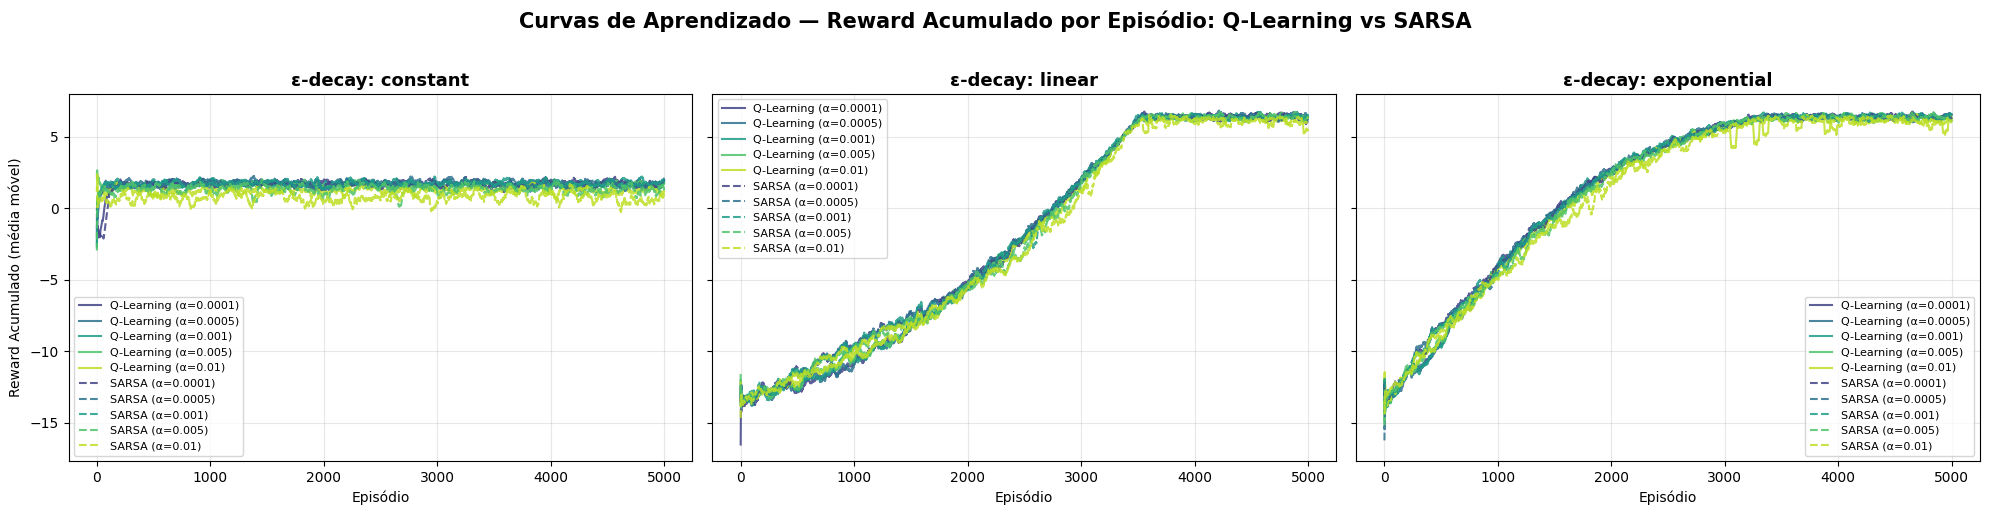

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(LEARNING_RATES)))
SMOOTH_WINDOW = 50  # janela para média móvel
gamma = GAMMA_VALUES[0]
# Dicionário para estilos de linha diferenciando visualmente os agentes
line_styles = {"Q-Learning": "-", "SARSA": "--"}
for ax_idx, decay_type in enumerate(EPSILON_DECAY_TYPES):
    ax = axes[ax_idx]
    ax.set_title(f"ε-decay: {decay_type}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Episódio")
    if ax_idx == 0:
        ax.set_ylabel("Reward Acumulado (média móvel)")

    # Iteramos sobre os agentes além dos learning rates e dos gammas
    for agent_type in AGENT_TYPES:
        for lr_idx, lr in enumerate(LEARNING_RATES):
            key = (agent_type, decay_type, lr, gamma)
            
            # Garantia caso alguma combinação não tenha sido treinada
            if key not in results:
                continue

            rewards = results[key]["metrics"]["episode_rewards"]
            # Média móvel para suavizar
            smoothed = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
            ax.plot(smoothed, 
                    label=f"{agent_type} (α={lr})", 
                    color=colors[lr_idx], 
                    linestyle=line_styles[agent_type],
                    linewidth=1.5,
                    alpha = 0.85)

    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Curvas de Aprendizado — Reward Acumulado por Episódio: Q-Learning vs SARSA", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 — Comparação entre Estratégias de Exploração

Para cada learning rate, compara os três tipos de decaimento.

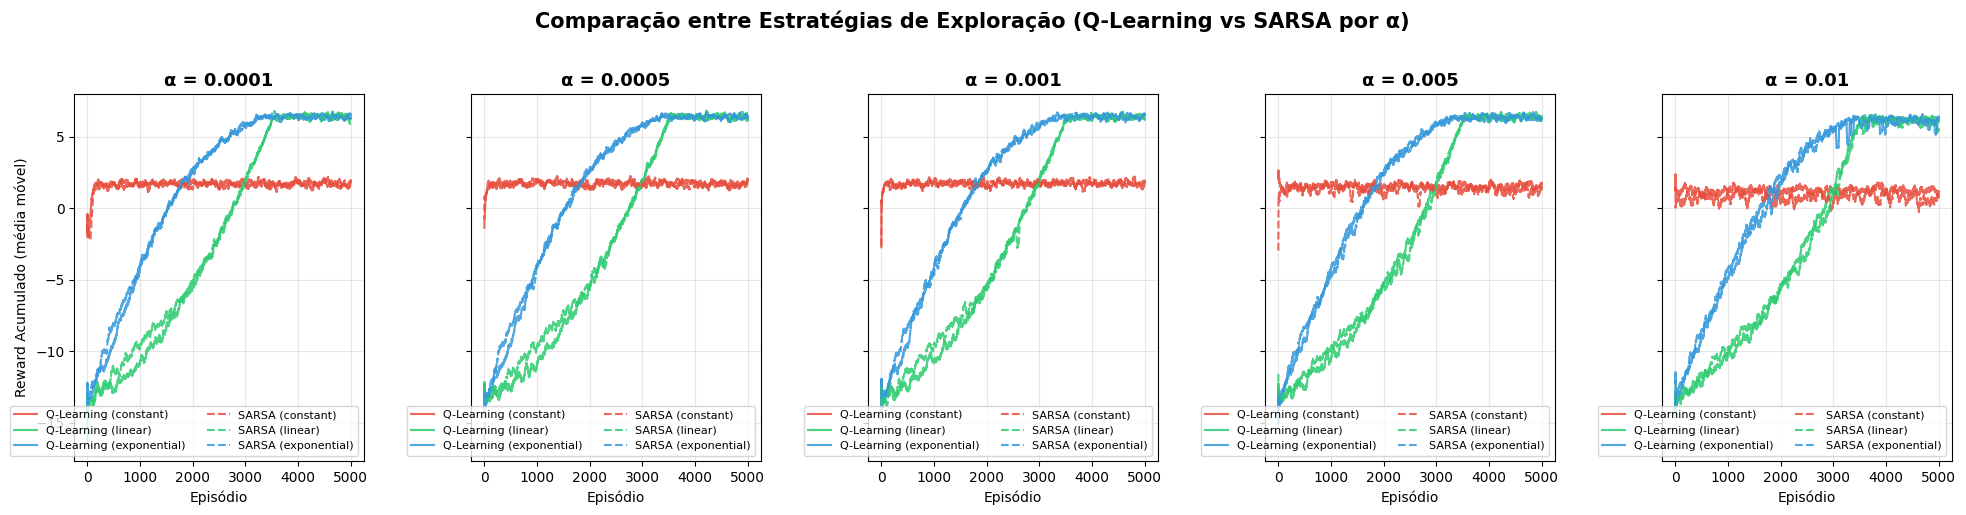

In [32]:
fig, axes = plt.subplots(1, len(LEARNING_RATES), figsize=(20, 5), sharey=True)
decay_colors = {"constant": "#e74c3c", "linear": "#2ecc71", "exponential": "#3498db"}
line_styles = {"Q-Learning": "-", "SARSA": "--"}
gamma = GAMMA_VALUES[0]

for ax_idx, lr in enumerate(LEARNING_RATES):
    ax = axes[ax_idx]
    ax.set_title(f"α = {lr}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Episódio")
    if ax_idx == 0:
        ax.set_ylabel("Reward Acumulado (média móvel)")

    for agent_type in AGENT_TYPES:
        for decay_type in EPSILON_DECAY_TYPES:
            key = (agent_type, decay_type, lr, gamma)
            
            # Verificação de segurança
            if key not in results:
                continue

            rewards = results[key]["metrics"]["episode_rewards"]
            smoothed = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
            ax.plot(
                smoothed, 
                label=f"{agent_type} ({decay_type})", 
                color=decay_colors[decay_type], 
                linestyle=line_styles[agent_type],
                linewidth=1.5,
                alpha=0.85
            )
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle("Comparação entre Estratégias de Exploração (Q-Learning vs SARSA por α)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 — Evolução do Epsilon ao Longo dos Episódios

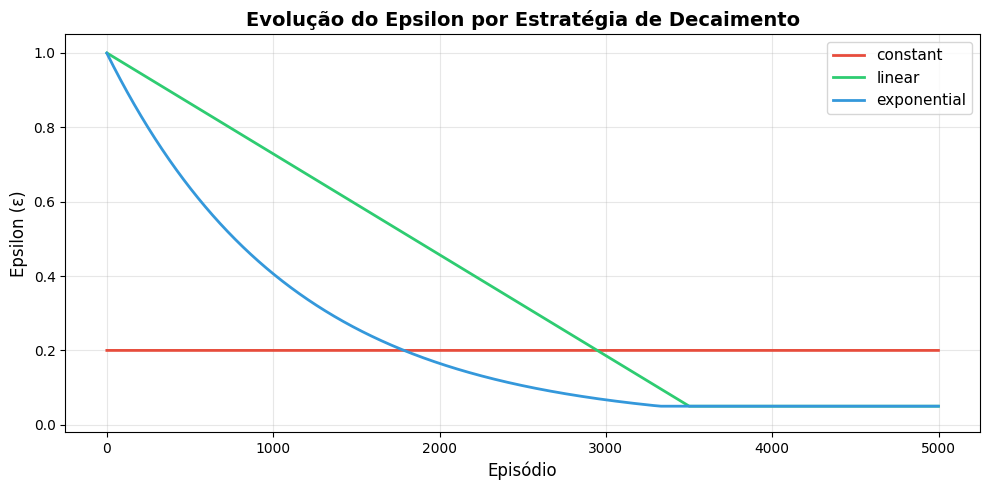

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

for decay_type in EPSILON_DECAY_TYPES:
    # Epsilon é igual para todos os LRs com o mesmo decay, usamos o primeiro
    agent_type = AGENT_TYPES[0]
    lr = LEARNING_RATES[0]
    gamma = GAMMA_VALUES[0]
    key = (agent_type, decay_type, lr, gamma)
    if key in results:
        epsilons = results[key]["metrics"]["episode_epsilons"]
        ax.plot(epsilons, label=decay_type, color=decay_colors[decay_type], linewidth=2)
    
ax.set_xlabel("Episódio", fontsize=12)
ax.set_ylabel("Epsilon (ε)", fontsize=12)
ax.set_title("Evolução do Epsilon por Estratégia de Decaimento", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

### 4.4 — Análise do impacto do fator de desconto

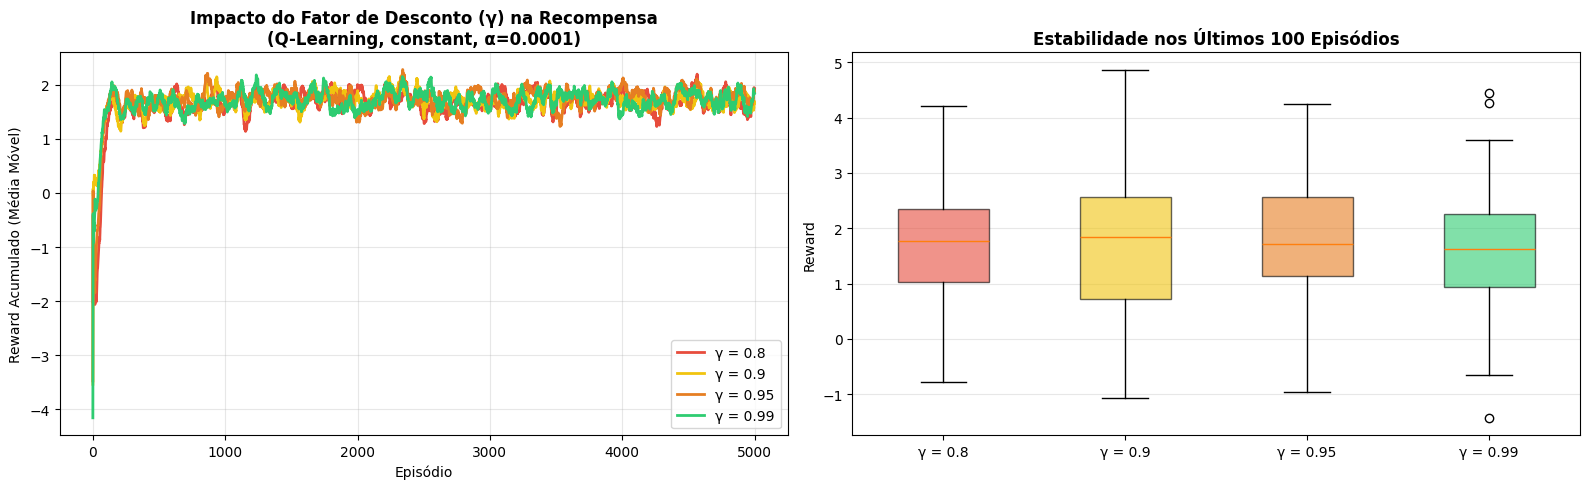

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
SMOOTH_WINDOW = 50

agent = AGENT_TYPES[0] 
decay_type = EPSILON_DECAY_TYPES[0]
lr = LEARNING_RATES[0] 

gamma_colors = {0.8: "#e74c3c", 0.9: "#f1c40f", 0.95: "#e67e22", 0.99: "#2ecc71"}

for gamma in GAMMA_VALUES:
    key = (agent, decay_type, lr, gamma)
    
    if key in results:
        rewards = results[key]["metrics"]["episode_rewards"]
        smoothed = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
        
        # Gráfico 1: Curva de Aprendizado por Gamma
        axes[0].plot(smoothed, label=f"γ = {gamma}", color=gamma_colors[gamma], linewidth=2)
        
        # Preparação para Gráfico 2: Histograma/Boxplot de estabilidade nos últimos 100 eps
        last_100 = rewards[-100:]
        axes[1].boxplot(last_100, positions=[GAMMA_VALUES.index(gamma)], widths=0.5, 
                        patch_artist=True, boxprops=dict(facecolor=gamma_colors[gamma], alpha=0.6))

# Formatação Eixo 0 (Curvas)
axes[0].set_title(f"Impacto do Fator de Desconto (γ) na Recompensa\n({agent}, {decay_type}, α={lr})", fontweight="bold")
axes[0].set_xlabel("Episódio")
axes[0].set_ylabel("Reward Acumulado (Média Móvel)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Formatação Eixo 1 (Estabilidade/Boxplot)
axes[1].set_title("Estabilidade nos Últimos 100 Episódios", fontweight="bold")
axes[1].set_xticks(range(len(GAMMA_VALUES)))
axes[1].set_xticklabels([f"γ = {g}" for g in GAMMA_VALUES])
axes[1].set_ylabel("Reward")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 — Reward Médio dos Últimos 100 Episódios (Heatmap)

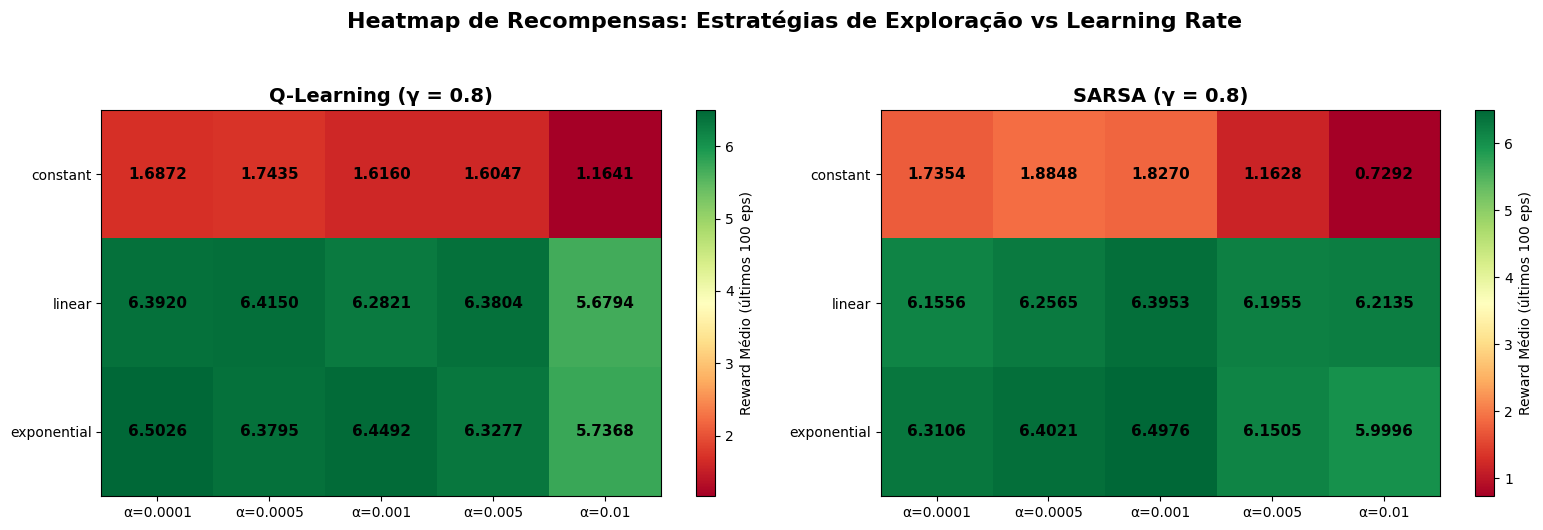

In [35]:
gamma = GAMMA_VALUES[0] # Escolha arbitrária
# Criamos 2 gráficos lado a lado (1 para Q-Learning, 1 para SARSA)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_idx, agent_type in enumerate(AGENT_TYPES):
    ax = axes[ax_idx]
    
    # Monta matriz 2D para o heatmap deste agente
    heatmap_data = np.zeros((len(EPSILON_DECAY_TYPES), len(LEARNING_RATES)))
    for i, decay_type in enumerate(EPSILON_DECAY_TYPES):
        for j, lr in enumerate(LEARNING_RATES):
            key = (agent_type, decay_type, lr, gamma)
            if key in results:
                rewards = results[key]["metrics"]["episode_rewards"]
                heatmap_data[i, j] = np.mean(rewards[-100:])

    im = ax.imshow(heatmap_data, cmap="RdYlGn", aspect="auto")

    ax.set_xticks(range(len(LEARNING_RATES)))
    ax.set_xticklabels([f"α={lr}" for lr in LEARNING_RATES])
    ax.set_yticks(range(len(EPSILON_DECAY_TYPES)))
    ax.set_yticklabels(EPSILON_DECAY_TYPES)

    # Anota valores
    for i in range(len(EPSILON_DECAY_TYPES)):
        for j in range(len(LEARNING_RATES)):
            ax.text(j, i, f"{heatmap_data[i, j]:.4f}", ha="center", va="center", fontsize=11, fontweight="bold")

    ax.set_title(f"{agent_type} (γ = {gamma})", fontsize=14, fontweight="bold")
    fig.colorbar(im, ax=ax, label="Reward Médio (últimos 100 eps)")
    
plt.suptitle("Heatmap de Recompensas: Estratégias de Exploração vs Learning Rate", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

### 4.6 — Q-Table da Melhor Configuração

In [36]:
# Identifica a melhor configuração (maior reward médio nos últimos 100 eps)
best_key = max(results.keys(), key=lambda k: np.mean(results[k]["metrics"]["episode_rewards"][-100:]))
best_agent = results[best_key]["agent"]
best_reward = np.mean(results[best_key]["metrics"]["episode_rewards"][-100:])

print(f"Melhor configuração: Agente={best_key[0]} decay={best_key[1]}, α={best_key[2]}, γ={best_key[3]}")
print(f"Reward médio (últimos 100 eps): {best_reward:.4f}")
print(f"Estados na Q-table: {len(best_agent.q_table)}")
print(f"Dimensões da Q-table: {len(best_agent.q_table.shape)}")
print()

# Exibe Q-table como DataFrame
q_df = best_agent.q_table_as_dataframe()
q_df["best_action"] = q_df[["q_sell(-1)", "q_hold(0)", "q_buy(1)"]].idxmax(axis=1)
q_df

Melhor configuração: Agente=SARSA decay=linear, α=0.0001, γ=0.9
Reward médio (últimos 100 eps): 6.5932
Estados na Q-table: 2
Dimensões da Q-table: 5



,state,q_sell(-1),q_hold(0),q_buy(1),best_action
0,"(0, 0, 0, 0)",1.058552e-02,0.010673,0.022521,q_buy(1)
1,"(0, 0, 0, 1)",-4.525096e-04,0.000742,-0.001016,q_hold(0)
2,"(0, 0, 1, 0)",9.063567e-03,0.008748,-0.010988,q_sell(-1)
3,"(0, 0, 1, 1)",-9.101969e-03,0.006526,-0.049883,q_hold(0)
4,"(0, 1, 0, 0)",2.582380e-07,-0.000119,-0.000124,q_sell(-1)
5,"(0, 1, 0, 1)",-3.101359e-06,0.000008,-0.000006,q_hold(0)
6,"(0, 1, 1, 0)",-2.526346e-04,0.000033,-0.000363,q_hold(0)
7,"(0, 1, 1, 1)",-7.771264e-05,0.000010,-0.000144,q_hold(0)
8,"(1, 0, 0, 0)",8.241561e-03,0.019453,0.020653,q_buy(1)
9,"(1, 0, 0, 1)",-6.921235e-04,-0.001228,-0.001194,q_sell(-1)


### 4.7 - Mapa de Valores $V(s)$ e Política Aprendida $π(s)$

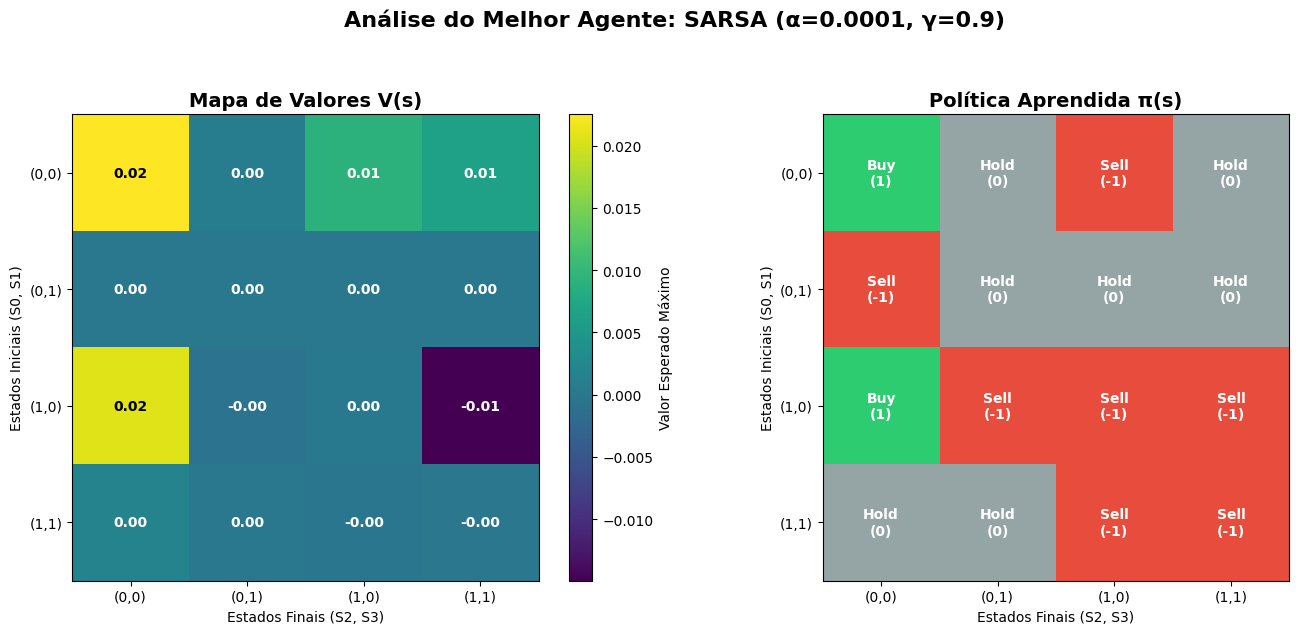

In [37]:
v_map = np.zeros((4, 4))
policy_map = np.zeros((4, 4))

action_names = {0: "Sell\n(-1)", 1: "Hold\n(0)", 2: "Buy\n(1)"}
action_colors = {0: "#e74c3c", 1: "#95a5a6", 2: "#2ecc71"} 

# Rótulos para os eixos combinando os estados binários (S0,S1) e (S2,S3)
axis_labels = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]

# Preencher as matrizes iterando sobre as 4 dimensões do estado
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            for s3 in range(2):
                row = s0 * 2 + s1
                col = s2 * 2 + s3
                
                # Extrai as 3 ações possíveis para este estado específico
                q_values = best_agent.q_table[s0, s1, s2, s3]
                
                # V(s) = max Q(s,a)
                v_map[row, col] = np.max(q_values)
                
                # Política = argmax Q(s,a)
                policy_map[row, col] = np.argmax(q_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Mapa de Valores V(s) ---
im_v = axes[0].imshow(v_map, cmap="viridis")
axes[0].set_title("Mapa de Valores V(s)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Estados Finais (S2, S3)")
axes[0].set_ylabel("Estados Iniciais (S0, S1)")
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(axis_labels)
axes[0].set_yticklabels(axis_labels)

# Anotações dos valores de V(s)
for i in range(4):
    for j in range(4):
        text_color = "black" if v_map[i, j] > np.max(v_map)*0.7 else "white"
        axes[0].text(j, i, f"{v_map[i, j]:.2f}", ha="center", va="center", color=text_color, fontweight="bold")

fig.colorbar(im_v, ax=axes[0], label="Valor Esperado Máximo")

# --- Gráfico 2: Política Aprendida π(s) ---
policy_rgb = np.zeros((4, 4, 3))
for i in range(4):
    for j in range(4):
        action_idx = int(policy_map[i, j])
        hex_color = action_colors[action_idx].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
        policy_rgb[i, j] = rgb

axes[1].imshow(policy_rgb)
axes[1].set_title("Política Aprendida π(s)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Estados Finais (S2, S3)")
axes[1].set_ylabel("Estados Iniciais (S0, S1)")
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(axis_labels)
axes[1].set_yticklabels(axis_labels)

# Anotações das ações na Política
for i in range(4):
    for j in range(4):
        action_idx = int(policy_map[i, j])
        axes[1].text(j, i, action_names[action_idx], ha="center", va="center", color="white", fontweight="bold")

plt.suptitle(f"Análise do Melhor Agente: {best_key[0]} (α={best_key[2]}, γ={best_key[3]})", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

### 4.8 - Vizualização do tempo de convergência

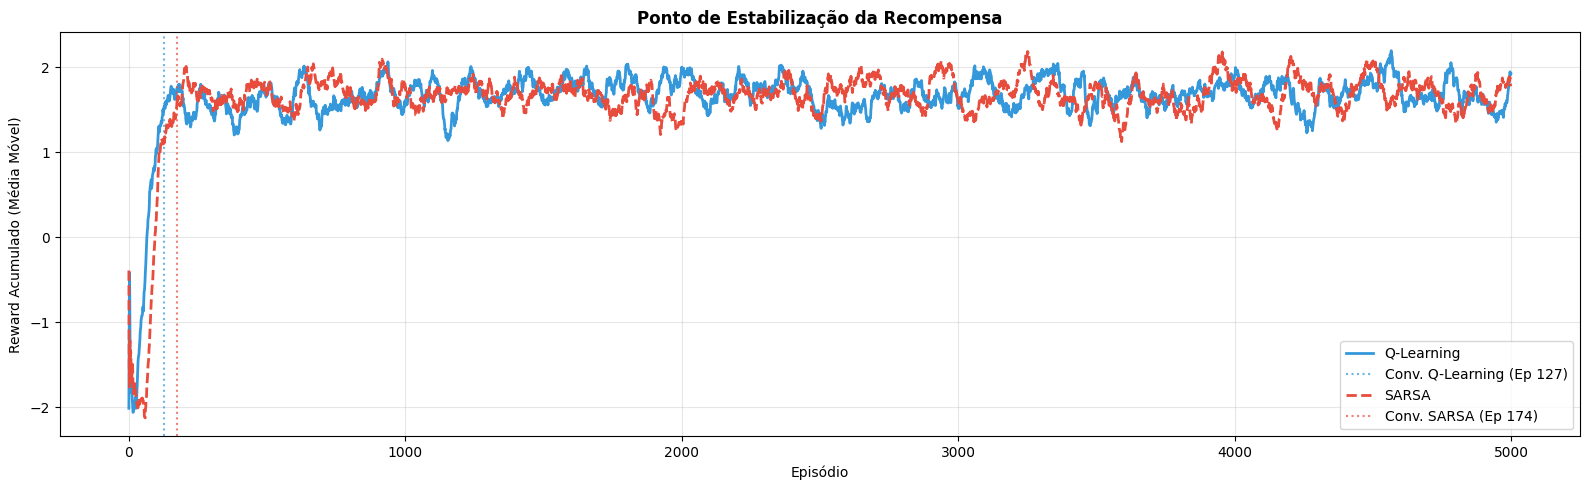

In [38]:
fig, ax = plt.subplots(figsize=(16, 5))
SMOOTH_WINDOW = 50

decay_type = EPSILON_DECAY_TYPES[0] 
lr = LEARNING_RATES[0]
gamma = GAMMA_VALUES[0]

line_styles = {"Q-Learning": "-", "SARSA": "--"}
colors = {"Q-Learning": "#3498db", "SARSA": "#e74c3c"}

for agent_type in AGENT_TYPES:
    key = (agent_type, decay_type, lr, gamma)
    
    if key in results:
        # Extrai as métricas
        steps = results[key]["metrics"]["episode_steps"]
        rewards = results[key]["metrics"]["episode_rewards"]
        
        # Suavização para melhor visualização
        smoothed_steps = pd.Series(steps).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
        smoothed_rewards = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
        
        # Identificação visual do ponto de convergência (Recompensa) 
        ax.plot(
            smoothed_rewards, 
            label=f"{agent_type}", 
            color=colors[agent_type], 
            linestyle=line_styles[agent_type], 
            linewidth=2
        )
        
        # Cálculo heurístico do episódio de convergência (atingiu 90% da performance final)
        final_performance = np.mean(rewards[-100:])
        threshold = final_performance * 0.90
        
        # Encontra o primeiro episódio (após a janela de suavização) que passa o threshold
        # Usamos try/except caso o threshold não seja atingido de forma clara
        try:
            convergence_ep = smoothed_rewards[smoothed_rewards >= threshold].index[0]
            # Desenha uma linha vertical marcando onde o algoritmo convergiu
            ax.axvline(x=convergence_ep, color=colors[agent_type], linestyle=":", alpha=0.7, 
                            label=f"Conv. {agent_type} (Ep {convergence_ep})")
        except:
            pass

# Formatação (Convergence Point)
ax.set_title("Ponto de Estabilização da Recompensa", fontweight="bold")
ax.set_xlabel("Episódio")
ax.set_ylabel("Reward Acumulado (Média Móvel)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Avaliação no Dataset de Teste

Avaliação greedy (sem exploração) de cada agente treinado no dataset de teste.

In [39]:
# Avalia todos os agentes no dataset de teste
test_results = {}

for key, data in results.items():
    agent = data["agent"]
    eval_result = evaluate_agent(TEST_DATA_PATH, agent)
    test_results[key] = eval_result

# Monta tabela de resultados
rows = []
for (agent_type, decay_type, lr, gamma), eval_data in test_results.items():
    train_reward = np.mean(results[(agent_type, decay_type, lr, gamma)]["metrics"]["episode_rewards"][-100:])
    rows.append({
        "Agente":   agent_type,
        "Decay Type":       decay_type,
        "Learning Rate (α)": lr,
        "Fator de Desconto (γ)": gamma,
        "Reward Treino (últimos 100 eps)": round(train_reward, 4),
        "Reward Teste (total)":            round(eval_data["total_reward"], 4),
    })

test_df = pd.DataFrame(rows).sort_values("Reward Teste (total)", ascending=False)
test_df.reset_index(drop=True, inplace=True)
test_df

,Agente,Decay Type,Learning Rate (α),Fator de Desconto (γ),Reward Treino (últimos 100 eps),Reward Teste (total)
0,Q-Learning,exponential,0.0100,0.90,6.0815,6.0017
1,SARSA,constant,0.0005,0.80,1.8848,5.6172
2,Q-Learning,linear,0.0010,0.99,6.3802,5.5456
3,SARSA,linear,0.0050,0.95,6.3645,5.5347
4,Q-Learning,constant,0.0005,0.80,1.7435,5.2868
...,...,...,...,...,...,...
115,SARSA,constant,0.0010,0.90,1.6811,3.7884
116,SARSA,linear,0.0010,0.95,6.3675,3.7866
117,SARSA,constant,0.0010,0.99,1.7380,3.7538
118,SARSA,constant,0.0100,0.90,1.2170,3.7325


### 5.1 — Comparação Visual: Treino vs. Teste

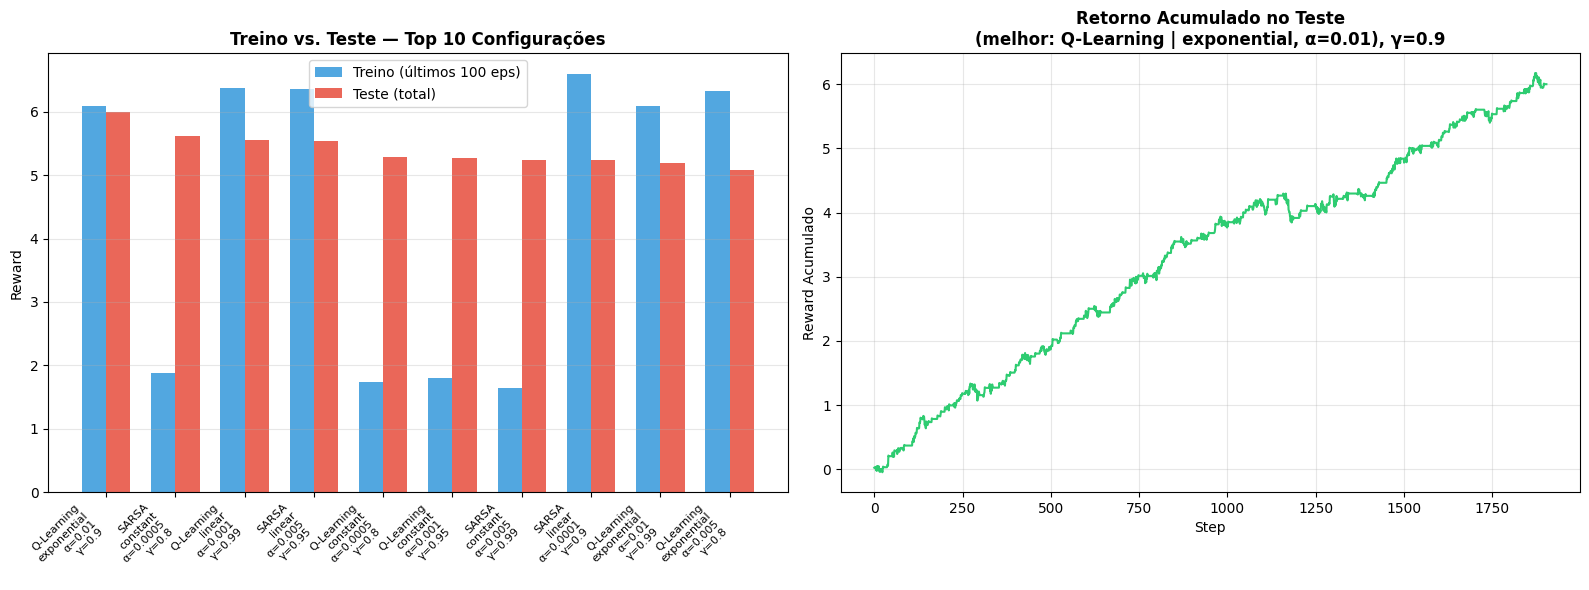

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filtra apenas as Top 10 melhores configurações para o gráfico de barras
top_df = test_df.head(10)

# Organiza dados para barplot
labels = [f"{a}\n{d}\nα={lr}\nγ={g}" for (a, d, lr, g) in top_df[["Agente", "Decay Type", "Learning Rate (α)", "Fator de Desconto (γ)"]].values]
train_vals = top_df["Reward Treino (últimos 100 eps)"].values
test_vals  = top_df["Reward Teste (total)"].values

x = np.arange(len(labels))
width = 0.35

# Barplot lado a lado
axes[0].bar(x - width/2, train_vals, width, label="Treino (últimos 100 eps)", color="#3498db", alpha=0.85)
axes[0].bar(x + width/2, test_vals,  width, label="Teste (total)",            color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8, rotation=45, ha="right")
axes[0].set_ylabel("Reward")
axes[0].set_title("Treino vs. Teste — Top 10 Configurações", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Retorno acumulado no teste da melhor configuração
best_test_key = (test_df.iloc[0]["Agente"],
                 test_df.iloc[0]["Decay Type"], 
                 test_df.iloc[0]["Learning Rate (α)"],
                 test_df.iloc[0]["Fator de Desconto (γ)"]
                )
best_step_rewards = test_results[best_test_key]["step_rewards"]
cumulative = np.cumsum(best_step_rewards)

axes[1].plot(cumulative, color="#2ecc71", linewidth=1.5)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Reward Acumulado")
axes[1].set_title(f"Retorno Acumulado no Teste\n(melhor: {best_test_key[0]} | {best_test_key[1]}, α={best_test_key[2]}), γ={best_test_key[3]}", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 — Trajetória do Agente (Posições no Teste)

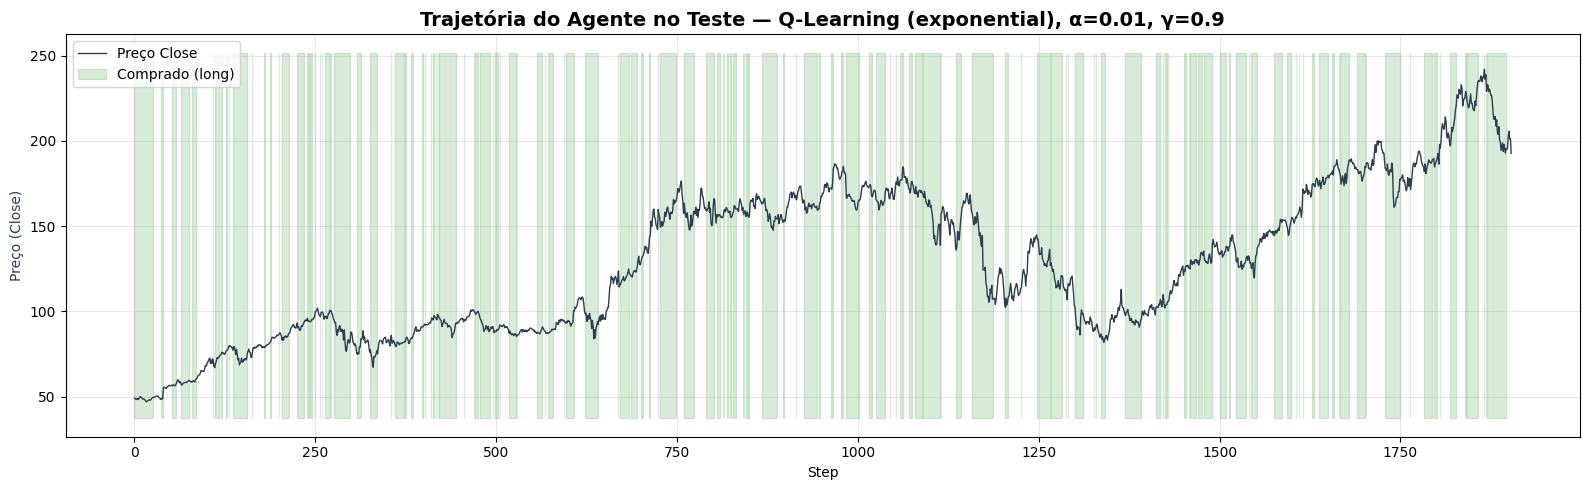

Steps comprado: 939 (49.3%)
Steps fora:     965 (50.7%)


In [41]:
# Carrega preços de teste para visualização
test_prices = pd.read_csv(TEST_DATA_PATH)["Close"].values

best_positions = test_results[best_test_key]["positions"]

fig, ax1 = plt.subplots(figsize=(16, 5))

# Preço
ax1.plot(test_prices[1:len(best_positions)+1], color="#2c3e50", linewidth=1, label="Preço Close")
ax1.set_xlabel("Step")
ax1.set_ylabel("Preço (Close)", color="#2c3e50")

# Marca regiões onde o agente está comprado (position=1)
pos_array = np.array(best_positions)
ax1.fill_between(
    range(len(pos_array)),
    ax1.get_ylim()[0], ax1.get_ylim()[1],
    where=pos_array == 1,
    alpha=0.15, color="green", label="Comprado (long)"
)

ax1.legend(loc="upper left")
ax1.set_title(f"Trajetória do Agente no Teste — {best_test_key[0]} ({best_test_key[1]}), α={best_test_key[2]}, γ={best_key[3]}", fontsize=14, fontweight="bold")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
n_long = sum(pos_array == 1)
n_out  = sum(pos_array == 0)
print(f"Steps comprado: {n_long} ({100*n_long/len(pos_array):.1f}%)")
print(f"Steps fora:     {n_out} ({100*n_out/len(pos_array):.1f}%)")

## 6 — Salvar Resultados em CSV

In [42]:
# Monta DataFrame com métricas de treino por episódio para todas as configurações
all_rows = []

for (agent_type, decay_type, lr, gamma), data in results.items():
    metrics = data["metrics"]
    for ep in range(len(metrics["episode_rewards"])):
        all_rows.append({
            "agent_type":      agent_type,
            "decay_type":      decay_type,
            "learning_rate":   lr,
            "gamma":           gamma,
            "episode":         ep,
            "reward":          metrics["episode_rewards"][ep],
            "epsilon":         metrics["episode_epsilons"][ep],
            "steps":           metrics["episode_steps"][ep],
        })

train_df = pd.DataFrame(all_rows)
train_df.to_csv("data/training_results.csv", index=False)
print(f"Salvo em data/training_results.csv — {len(train_df)} linhas")
train_df.head()

Salvo em data/training_results.csv — 600000 linhas


,agent_type,decay_type,learning_rate,gamma,episode,reward,epsilon,steps
0,Q-Learning,constant,0.0001,0.8,0,-2.013268,0.2,4442
1,Q-Learning,constant,0.0001,0.8,1,-0.534785,0.2,4442
2,Q-Learning,constant,0.0001,0.8,2,1.299239,0.2,4442
3,Q-Learning,constant,0.0001,0.8,3,-1.152039,0.2,4442
4,Q-Learning,constant,0.0001,0.8,4,-3.451079,0.2,4442
